In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test  = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample_sub = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

print(train.shape, test.shape)
train.head()

(198000, 15) (102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


### EDA

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [7]:
train.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [8]:
train.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

In [9]:
train.value_counts()

created_date                      post_id  emoticon_1  emoticon_2  emoticon_3  upvote  downvote  if_1  if_2  race   religion  gender  disability  comment                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

### Visualization

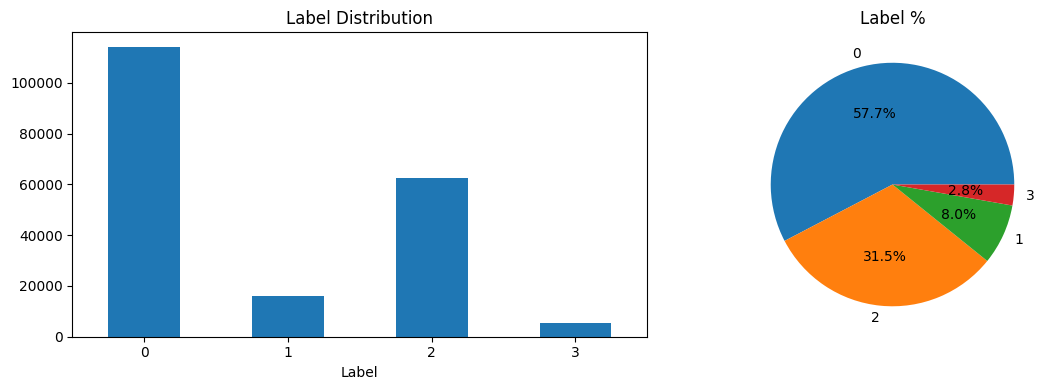

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train['label'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Label Distribution')
axes[0].set_xlabel('Label')
axes[0].tick_params(axis='x', rotation=0)

train['label'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Label %')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

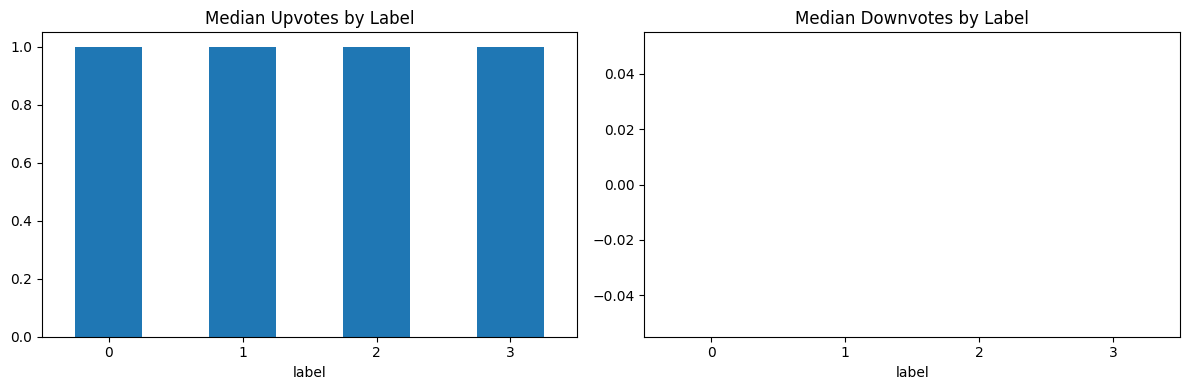

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train.groupby('label')['upvote'].median().plot(kind='bar', ax=axes[0])
axes[0].set_title('Median Upvotes by Label')
axes[0].tick_params(axis='x', rotation=0)

train.groupby('label')['downvote'].median().plot(kind='bar', ax=axes[1])
axes[1].set_title('Median Downvotes by Label')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

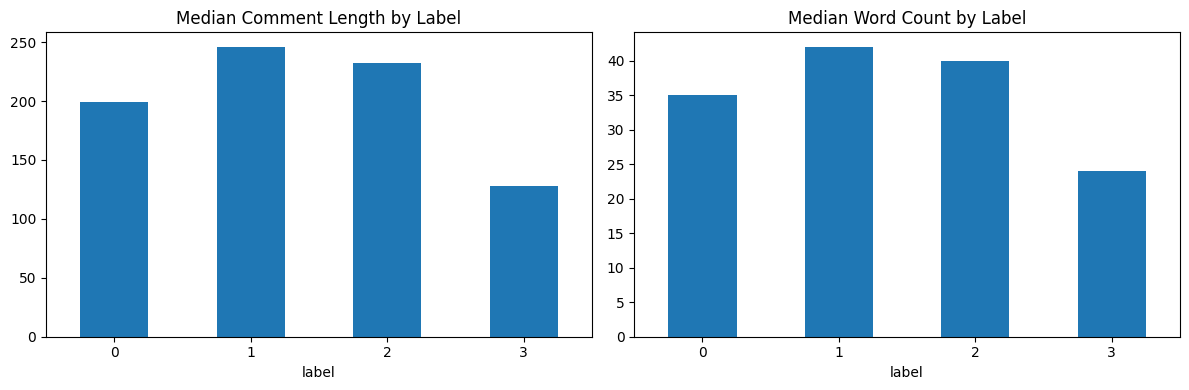

In [12]:
train['comment_len'] = train['comment'].fillna('').apply(len)
train['word_count']  = train['comment'].fillna('').apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train.groupby('label')['comment_len'].median().plot(kind='bar', ax=axes[0])
axes[0].set_title('Median Comment Length by Label')
axes[0].tick_params(axis='x', rotation=0)

train.groupby('label')['word_count'].median().plot(kind='bar', ax=axes[1])
axes[1].set_title('Median Word Count by Label')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

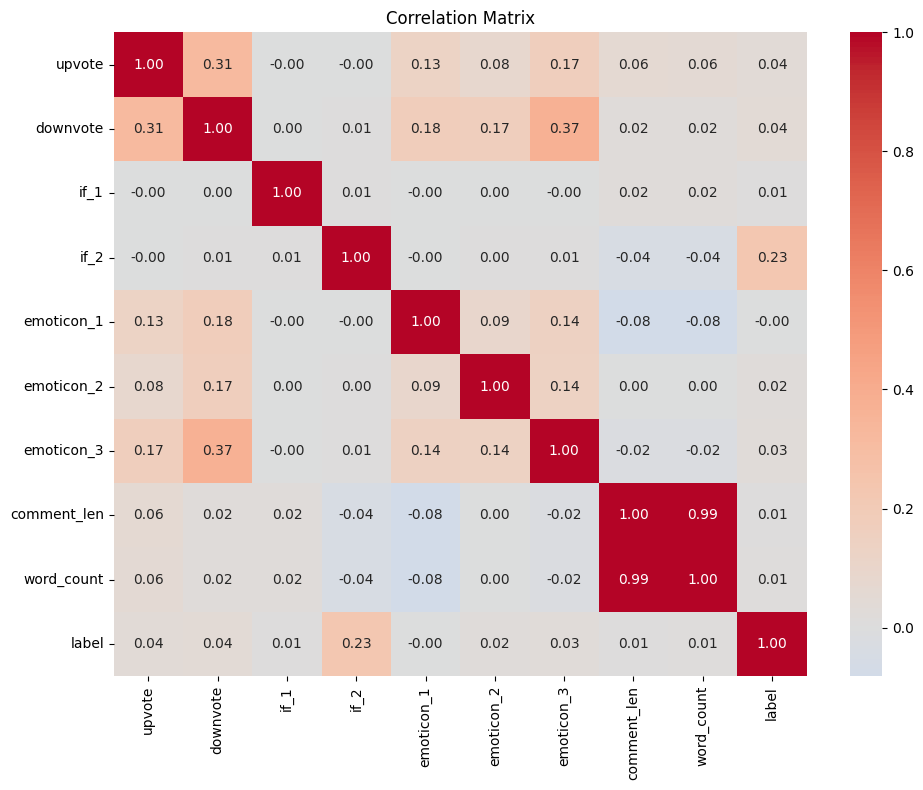

In [13]:
numeric_cols = ['upvote', 'downvote', 'if_1', 'if_2', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'comment_len', 'word_count', 'label']
plt.figure(figsize=(10, 8))
sns.heatmap(train[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Statistical Analysis

In [14]:
from scipy import stats

for col in ['upvote', 'downvote', 'if_2', 'comment_len', 'word_count']:
    groups = [train[train['label'] == lbl][col].dropna().values for lbl in sorted(train['label'].unique())]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f'{col:<20} F={f_stat:>10.2f}  p={p_val:.4e}')

upvote               F=    203.12  p=1.5132e-131
downvote             F=    214.92  p=3.3465e-139
if_2                 F=   4168.08  p=0.0000e+00
comment_len          F=    471.06  p=4.9590e-305
word_count           F=    414.76  p=1.2676e-268


In [15]:
train['label'].value_counts()

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

### Train-Validation Split

In [16]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_raw = train.drop(columns=['label', 'comment_len', 'word_count'])
y     = train['label'].values

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train_raw.shape} | Val: {X_val_raw.shape}')

Train: (158400, 14) | Val: (39600, 14)


### Preprocessing

In [17]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

def clean_text(text):
    if pd.isna(text): return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def add_features(df):
    df = df.copy()
    df['created_date'] = pd.to_datetime(df['created_date'], utc=True)
    df['hour']  = df['created_date'].dt.hour
    df['dow']   = df['created_date'].dt.dayofweek
    df['month'] = df['created_date'].dt.month
    df['comment_len']  = df['comment'].fillna('').apply(len)
    df['word_count']   = df['comment'].fillna('').apply(lambda x: len(x.split()))
    df['vote_diff']    = df['upvote'] - df['downvote']
    df['vote_ratio']   = df['upvote'] / (df['downvote'] + 1)
    df['emoticon_sum'] = df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']
    for col in ['race', 'religion', 'gender', 'disability']:
        df[col + '_flag'] = df[col].notna().astype(int)
    return df

STRUCT_COLS = ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
               'upvote', 'downvote', 'if_1', 'if_2',
               'hour', 'dow', 'month', 'comment_len', 'word_count',
               'vote_diff', 'vote_ratio', 'emoticon_sum',
               'race_flag', 'religion_flag', 'gender_flag', 'disability_flag']

X_train_eng = add_features(X_train_raw)
X_val_eng   = add_features(X_val_raw)
X_test_eng  = add_features(test.copy())

tfidf = TfidfVectorizer(preprocessor=clean_text, max_features=30000,
                        ngram_range=(1, 2), min_df=3, sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(X_train_eng['comment'].fillna(''))
X_val_tfidf   = tfidf.transform(X_val_eng['comment'].fillna(''))
X_test_tfidf  = tfidf.transform(X_test_eng['comment'].fillna(''))

scaler = StandardScaler()
X_train_struct = scaler.fit_transform(X_train_eng[STRUCT_COLS].fillna(0))
X_val_struct   = scaler.transform(X_val_eng[STRUCT_COLS].fillna(0))
X_test_struct  = scaler.transform(X_test_eng[STRUCT_COLS].fillna(0))

X_train_final = hstack([X_train_tfidf, csr_matrix(X_train_struct)])
X_val_final   = hstack([X_val_tfidf,   csr_matrix(X_val_struct)])
X_test_final  = hstack([X_test_tfidf,  csr_matrix(X_test_struct)])

print(f'Train: {X_train_final.shape} | Val: {X_val_final.shape} | Test: {X_test_final.shape}')

Train: (158400, 30020) | Val: (39600, 30020) | Test: (102000, 30020)


### Baseline Model

In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

results = []

def evaluate(name, y_true, y_pred):
    acc    = accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average='macro')
    f1_wtd = f1_score(y_true, y_pred, average='weighted')
    print(f'\n=== {name} ===')
    print(f'Accuracy    : {acc:.4f}')
    print(f'F1 Macro    : {f1_mac:.4f}')
    print(f'F1 Weighted : {f1_wtd:.4f}')
    print(classification_report(y_true, y_pred))
    return {'model': name, 'accuracy': acc, 'f1_macro': f1_mac, 'f1_weighted': f1_wtd}

dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train_final, y_train)
results.append(evaluate('Dummy', y_val, dummy.predict(X_val_final)))


=== Dummy ===
Accuracy    : 0.5766
F1 Macro    : 0.1829
F1 Weighted : 0.4218
              precision    recall  f1-score   support

           0       0.58      1.00      0.73     22835
           1       0.00      0.00      0.00      3183
           2       0.00      0.00      0.00     12488
           3       0.00      0.00      0.00      1094

    accuracy                           0.58     39600
   macro avg       0.14      0.25      0.18     39600
weighted avg       0.33      0.58      0.42     39600



### Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(solver='saga', max_iter=500, n_jobs=-1, random_state=RANDOM_STATE)
lr.fit(X_train_final, y_train)
results.append(evaluate('Logistic Regression', y_val, lr.predict(X_val_final)))


=== Logistic Regression ===
Accuracy    : 0.8913
F1 Macro    : 0.6988
F1 Weighted : 0.8845
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     22835
           1       0.77      0.67      0.72      3183
           2       0.80      0.91      0.85     12488
           3       0.89      0.16      0.27      1094

    accuracy                           0.89     39600
   macro avg       0.86      0.67      0.70     39600
weighted avg       0.89      0.89      0.88     39600



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':        [0.01, 0.1, 1.0, 10.0],
    'penalty':  ['l1', 'l2'],
    'solver':   ['saga'],
    'max_iter': [500],
}

lr_grid = GridSearchCV(
    LogisticRegression(n_jobs=-1, random_state=RANDOM_STATE),
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)
lr_grid.fit(X_train_final, y_train)

print(f'Best params : {lr_grid.best_params_}')
print(f'Best CV F1  : {lr_grid.best_score_:.4f}')

results.append(evaluate('Logistic Regression (tuned)', y_val, lr_grid.best_estimator_.predict(X_val_final)))

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

### Dimensionality Reduction (TruncatedSVD)

In [ ]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=300, random_state=RANDOM_STATE)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd   = svd.transform(X_val_tfidf)
X_test_svd  = svd.transform(X_test_tfidf)

X_train_svd_full = np.hstack([X_train_svd, X_train_struct])
X_val_svd_full   = np.hstack([X_val_svd,   X_val_struct])
X_test_svd_full  = np.hstack([X_test_svd,  X_test_struct])

plt.figure(figsize=(8, 4))
plt.plot(svd.explained_variance_ratio_.cumsum())
plt.axhline(0.8, color='red', linestyle='--', label='80%')
plt.xlabel('Components'); plt.ylabel('Cumulative Explained Variance')
plt.title('TruncatedSVD Explained Variance')
plt.legend(); plt.tight_layout(); plt.show()

### Feature Selection (Chi2)

In [21]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(chi2, k=15000)
X_train_chi2 = selector.fit_transform(X_train_tfidf, y_train)
X_val_chi2   = selector.transform(X_val_tfidf)
X_test_chi2  = selector.transform(X_test_tfidf)

X_train_chi2_full = hstack([X_train_chi2, csr_matrix(X_train_struct)])
X_val_chi2_full   = hstack([X_val_chi2,   csr_matrix(X_val_struct)])
X_test_chi2_full  = hstack([X_test_chi2,  csr_matrix(X_test_struct)])

print(f'Chi2 selected: {X_train_chi2_full.shape}')

Chi2 selected: (158400, 15020)


### Random Forest (Bagging)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300, max_depth=20, min_samples_leaf=5,
    max_features='sqrt', class_weight='balanced',
    n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_train_svd_full, y_train)
results.append(evaluate('Random Forest', y_val, rf.predict(X_val_svd_full)))

### LightGBM (Boosting)

In [ ]:
import lightgbm as lgb

num_classes = len(np.unique(y_train))

lgb_train_ds = lgb.Dataset(X_train_final, label=y_train)
lgb_val_ds   = lgb.Dataset(X_val_final,   label=y_val, reference=lgb_train_ds)

lgb_params = {
    'objective'       : 'multiclass',
    'num_class'       : num_classes,
    'metric'          : 'multi_logloss',
    'learning_rate'   : 0.05,
    'num_leaves'      : 63,
    'min_data_in_leaf': 30,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq'    : 5,
    'lambda_l1'       : 0.1,
    'lambda_l2'       : 0.1,
    'verbosity'       : -1,
    'seed'            : RANDOM_STATE,
    'n_jobs'          : -1
}

model_lgb = lgb.train(
    lgb_params, lgb_train_ds, num_boost_round=1200,
    valid_sets=[lgb_train_ds, lgb_val_ds],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(200)]
)

lgb_preds = np.argmax(model_lgb.predict(X_val_final), axis=1)
results.append(evaluate('LightGBM', y_val, lgb_preds))

### MLP

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=512,
    learning_rate_init=1e-3,
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=RANDOM_STATE,
    verbose=True
)
mlp.fit(X_train_svd_full, y_train)
results.append(evaluate('MLP (512-256-128)', y_val, mlp.predict(X_val_svd_full)))

In [ ]:
df_results = pd.DataFrame(results).sort_values('f1_macro', ascending=False)

plt.figure(figsize=(12, 5))
plt.barh(df_results['model'][::-1], df_results['f1_macro'][::-1])
plt.xlabel('F1 Macro')
plt.title('Model Comparison')
plt.tight_layout()
plt.show()

print(df_results[['model', 'accuracy', 'f1_macro', 'f1_weighted']].to_string(index=False))

### Improved Feature Engineering

In [ ]:
def add_features_v2(df):
    df = add_features(df)
    df['upper_ratio']       = df['comment'].fillna('').apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
    df['exclamation_count'] = df['comment'].fillna('').apply(lambda x: x.count('!'))
    df['question_count']    = df['comment'].fillna('').apply(lambda x: x.count('?'))
    df['has_url']           = df['comment'].fillna('').apply(lambda x: int(bool(re.search(r'http|www', x))))
    df['identity_sum']      = df['race_flag'] + df['religion_flag'] + df['gender_flag'] + df['disability_flag']
    df['if2_x_downvote']    = df['if_2'] * df['downvote']
    df['if2_x_wordcount']   = df['if_2'] * df['word_count']
    return df

STRUCT_COLS_V2 = STRUCT_COLS + ['upper_ratio', 'exclamation_count', 'question_count',
                                 'has_url', 'identity_sum', 'if2_x_downvote', 'if2_x_wordcount']

X_train_eng2 = add_features_v2(X_train_raw)
X_val_eng2   = add_features_v2(X_val_raw)
X_test_eng2  = add_features_v2(test.copy())

tfidf_v2 = TfidfVectorizer(preprocessor=clean_text, max_features=50000,
                            ngram_range=(1, 3), min_df=3, max_df=0.95, sublinear_tf=True)

X_train_tfidf2 = tfidf_v2.fit_transform(X_train_eng2['comment'].fillna(''))
X_val_tfidf2   = tfidf_v2.transform(X_val_eng2['comment'].fillna(''))
X_test_tfidf2  = tfidf_v2.transform(X_test_eng2['comment'].fillna(''))

scaler2 = StandardScaler()
X_train_struct2 = scaler2.fit_transform(X_train_eng2[STRUCT_COLS_V2].fillna(0))
X_val_struct2   = scaler2.transform(X_val_eng2[STRUCT_COLS_V2].fillna(0))
X_test_struct2  = scaler2.transform(X_test_eng2[STRUCT_COLS_V2].fillna(0))

X_train_v2 = hstack([X_train_tfidf2, csr_matrix(X_train_struct2)])
X_val_v2   = hstack([X_val_tfidf2,   csr_matrix(X_val_struct2)])
X_test_v2  = hstack([X_test_tfidf2,  csr_matrix(X_test_struct2)])

print(f'V2 matrix: {X_train_v2.shape}')

### LightGBM on V2 Features

In [ ]:
lgb_train2 = lgb.Dataset(X_train_v2, label=y_train)
lgb_val2   = lgb.Dataset(X_val_v2,   label=y_val, reference=lgb_train2)

lgb_params_v2 = {
    'objective'       : 'multiclass',
    'num_class'       : num_classes,
    'metric'          : 'multi_logloss',
    'learning_rate'   : 0.05,
    'num_leaves'      : 63,
    'min_data_in_leaf': 30,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq'    : 5,
    'lambda_l1'       : 0.1,
    'lambda_l2'       : 0.1,
    'verbosity'       : -1,
    'seed'            : RANDOM_STATE,
    'n_jobs'          : -1
}

model_lgb_v2 = lgb.train(
    lgb_params_v2, lgb_train2, num_boost_round=3000,
    valid_sets=[lgb_train2, lgb_val2],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(200)]
)

lgb_v2_preds = np.argmax(model_lgb_v2.predict(X_val_v2), axis=1)
results.append(evaluate('LightGBM v2', y_val, lgb_v2_preds))

### Final Leaderboard

In [ ]:
df_results = pd.DataFrame(results).sort_values('f1_macro', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.barh(df_results['model'][::-1], df_results['f1_macro'][::-1])
plt.xlabel('F1 Macro')
plt.title('All Models — Final Comparison')
plt.tight_layout()
plt.show()

print(df_results[['model', 'accuracy', 'f1_macro', 'f1_weighted']].to_string(index=False))

### Final Submission

In [ ]:
proba_lgb_test = model_lgb_v2.predict(X_test_v2)

final_preds = np.argmax(proba_lgb_test, axis=1)

print('Prediction distribution:', np.bincount(final_preds))

sample_sub['label'] = final_preds
sample_sub.to_csv('submission.csv', index=False)
print('submission.csv saved')
sample_sub.head()